In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [64]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("SampleSubmission.csv")
variable = pd.read_csv("VariableDefinitions.csv")

In [65]:
print (f"\nTrain shape:{train.shape}")
print (f"\nTest shape: {test.shape}")
print (f"\nTrain Variablea: {train.shape[1]}")
print (f"\nTest variable: {test.shape[1]}")


Train shape:(9618, 39)

Test shape: (2405, 38)

Train Variablea: 39

Test variable: 38


In [66]:
if "FHI" in train.columns and "FHI" not in test.colums:
    print(f"\ntarget variable is available")
    print(f"\ntarget variable is completely not available0")
else:
    print(f"\ncheck target variable present")


check target variable present


In [67]:
train.isnull().sum()

ID                                                                     0
country                                                                0
owner_age                                                              0
attitude_stable_business_environment                                   2
attitude_worried_shutdown                                              2
compliance_income_tax                                                  4
perception_insurance_doesnt_cover_losses                               5
perception_cannot_afford_insurance                                     5
personal_income                                                      109
business_expenses                                                    229
business_turnover                                                    216
business_age_years                                                   252
motor_vehicle_insurance                                             2244
has_mobile_money                                   

In [68]:
train

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9613,ID_D7NC2D,lesotho,31.0,Yes,No,No,Don't know,Don't know,2000.0,800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Have now,Never had,Medium
9614,ID_NT06RL,malawi,64.0,Don’t know or N/A,Don’t know or N/A,Yes,No,No,10000000.0,5000000.0,...,Never had,Have now,Yes,NaN,NaN,NaN,No,NaN,NaN,High
9615,ID_4TVWA3,zimbabwe,43.0,Yes,No,No,Yes,No,450.0,NaN,...,NaN,NaN,No,8.0,Have now,Have now,NaN,NaN,NaN,Medium
9616,ID_3U3S2Z,zimbabwe,38.0,Yes,Yes,No,No,Yes,2000.0,NaN,...,NaN,NaN,No,0.0,Never had,Never had,NaN,NaN,NaN,Low


In [69]:
test

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,ID_FX7XJZ,eswatini,29.0,Yes,Yes,No,No,Yes,600.0,1700.0,...,Never had,Never had,Never had,NaN,11.0,Never had,Never had,NaN,Never had,Never had
2401,ID_XAL1LX,malawi,20.0,Don’t know or N/A,Don’t know or N/A,No,Don't know,Don't know,30000.0,20000.0,...,Never had,Never had,Never had,No,4.0,NaN,NaN,Yes,NaN,NaN
2402,ID_UHBP0F,zimbabwe,26.0,Yes,Yes,No,Yes,Yes,3888.0,NaN,...,NaN,NaN,NaN,No,0.0,Have now,Have now,NaN,NaN,NaN
2403,ID_GKIKR2,eswatini,63.0,No,No,Yes,Yes,Yes,3500.0,1700.0,...,Never had,Never had,Never had,NaN,4.0,Never had,Have now,NaN,Never had,Never had


In [70]:
mapping = {"Yes":2, "No":1, "Don't know":3, "Never had":1, "Have now":2, "Female":1, "Male":2, "sometimes":1, "always":2, "Don't know":4}

In [71]:
test.isnull().sum()

ID                                                                     0
country                                                                0
owner_age                                                              1
attitude_stable_business_environment                                   0
attitude_worried_shutdown                                              0
compliance_income_tax                                                  0
perception_insurance_doesnt_cover_losses                               2
perception_cannot_afford_insurance                                     2
personal_income                                                       23
business_expenses                                                     70
business_turnover                                                     70
business_age_years                                                    59
motor_vehicle_insurance                                              557
has_mobile_money                                   

In [72]:
test["attitude_stable_business_environment"] = test["attitude_stable_business_environment"].map(mapping) 
test["attitude_worried_shutdown"] = test["attitude_worried_shutdown"].map(mapping)
test["compliance_income_tax"] = test["compliance_income_tax"].map(mapping)
test["perception_insurance_doesnt_cover_losses"] = test["perception_insurance_doesnt_cover_losses"].map(mapping)
test["perception_cannot_afford_insurance"] = test["perception_cannot_afford_insurance"].map(mapping)
test["future_risk_theft_stock"] = test["future_risk_theft_stock"].map(mapping)
test["motivation_make_more_money"] = test["motivation_make_more_money"].map(mapping)
test["has_internet_banking"] = test["has_internet_banking"].map(mapping)
test["has_debit_card"] = test["has_debit_card"].map(mapping)
test["medical_insurance"] = test["medical_insurance"].map(mapping)
test["uses_friends_family_savings"] = test["uses_friends_family_savings"].map(mapping)
test["uses_informal_lender"] = test["uses_informal_lender"].map(mapping)
test["motor_vehicle_insurance"] = test["motor_vehicle_insurance"].map(mapping)
test["has_mobile_money"] = test["has_mobile_money"].map(mapping)
test["current_problem_cash_flow"] = test["current_problem_cash_flow"].map(mapping)
test["has_cellphone"] = test["has_cellphone"].map(mapping)
test["owner_sex"] = test["owner_sex"].map(mapping)
test["offers_credit_to_customers"] = test["offers_credit_to_customers"].map(mapping)
test["attitude_satisfied_with_achievement"] = test["attitude_satisfied_with_achievement"].map(mapping)
test["has_credit_card"] = test["has_credit_card"].map(mapping)
test["keeps_financial_records"] = test["keeps_financial_records"].map(mapping)
test["perception_insurance_companies_dont_insure_businesses_like_yours"] = test["perception_insurance_companies_dont_insure_businesses_like_yours"].map(mapping)
test["perception_insurance_important"] = test["perception_insurance_important"].map(mapping)
test["has_insurance"] = test["has_insurance"].map(mapping)
test["covid_essential_service"] = test["covid_essential_service"].map(mapping)
test["attitude_more_successful_next_year"] = test["attitude_more_successful_next_year"].map(mapping)
test["problem_sourcing_money"] = test["problem_sourcing_money"].map(mapping)
test["marketing_word_of_mouth"] = test["marketing_word_of_mouth"].map(mapping)
test["has_loan_account"] = test["has_loan_account"].map(mapping)
test["funeral_insurance"] = test["funeral_insurance"].map(mapping)

In [73]:
train["attitude_stable_business_environment"] = train["attitude_stable_business_environment"].map(mapping) 
train["attitude_worried_shutdown"] = train["attitude_worried_shutdown"].map(mapping)
train["compliance_income_tax"] = train["compliance_income_tax"].map(mapping)
train["perception_insurance_doesnt_cover_losses"] = train["perception_insurance_doesnt_cover_losses"].map(mapping)
train["perception_cannot_afford_insurance"] = train["perception_cannot_afford_insurance"].map(mapping)
train["future_risk_theft_stock"] = train["future_risk_theft_stock"].map(mapping)
train["motivation_make_more_money"] = train["motivation_make_more_money"].map(mapping)
train["has_internet_banking"] = train["has_internet_banking"].map(mapping)
train["has_debit_card"] = train["has_debit_card"].map(mapping)
train["medical_insurance"] = train["medical_insurance"].map(mapping)
train["uses_friends_family_savings"] = train["uses_friends_family_savings"].map(mapping)
train["uses_informal_lender"] = train["uses_informal_lender"].map(mapping)
train["motor_vehicle_insurance"] = train["motor_vehicle_insurance"].map(mapping)
train["has_mobile_money"] = train["has_mobile_money"].map(mapping)
train["current_problem_cash_flow"] = train["current_problem_cash_flow"].map(mapping)
train["has_cellphone"] = train["has_cellphone"].map(mapping)
train["owner_sex"] = train["owner_sex"].map(mapping)
train["offers_credit_to_customers"] = train["offers_credit_to_customers"].map(mapping)
train["attitude_satisfied_with_achievement"] = train["attitude_satisfied_with_achievement"].map(mapping)
train["has_credit_card"] = train["has_credit_card"].map(mapping)
train["keeps_financial_records"] = train["keeps_financial_records"].map(mapping)
train["perception_insurance_companies_dont_insure_businesses_like_yours"] = train["perception_insurance_companies_dont_insure_businesses_like_yours"].map(mapping)
train["perception_insurance_important"] = train["perception_insurance_important"].map(mapping)
train["has_insurance"] = train["has_insurance"].map(mapping)
train["covid_essential_service"] = train["covid_essential_service"].map(mapping)
train["attitude_more_successful_next_year"] = train["attitude_more_successful_next_year"].map(mapping)
train["problem_sourcing_money"] = train["problem_sourcing_money"].map(mapping)
train["marketing_word_of_mouth"] = train["marketing_word_of_mouth"].map(mapping)
train["has_loan_account"] = train["has_loan_account"].map(mapping)
train["funeral_insurance"] = train["funeral_insurance"].map(mapping)

In [74]:
test["attitude_stable_business_environment"] = test["attitude_stable_business_environment"].fillna(test["attitude_stable_business_environment"].mode()[0])
test["attitude_worried_shutdown"] = test["attitude_worried_shutdown"].fillna(test["attitude_worried_shutdown"].mode()[0])
test["compliance_income_tax"] = test["compliance_income_tax"].fillna(test["compliance_income_tax"].mode()[0])
test["perception_insurance_doesnt_cover_losses"] = test["perception_insurance_doesnt_cover_losses"].fillna(test["perception_insurance_doesnt_cover_losses"].mode()[0])
test["perception_cannot_afford_insurance"] = test["perception_cannot_afford_insurance"].fillna(test["perception_cannot_afford_insurance"].mode()[0])
test["future_risk_theft_stock"] = test["future_risk_theft_stock"].fillna(test["future_risk_theft_stock"].mode()[0])
test["motivation_make_more_money"] = test["motivation_make_more_money"].fillna(test["motivation_make_more_money"].mode()[0])
test["has_internet_banking"] = test["has_internet_banking"].fillna(test["has_internet_banking"].mode()[0])
test["has_debit_card"] = test["has_debit_card"].fillna(test["has_debit_card"].mode()[0])
test["medical_insurance"] = test["medical_insurance"].fillna(test["medical_insurance"].mode()[0])
test["uses_friends_family_savings"] = test["uses_friends_family_savings"].fillna(test["uses_friends_family_savings"].mode()[0])
test["uses_informal_lender"] = test["uses_informal_lender"].fillna(test["uses_informal_lender"].mode()[0])
test["motor_vehicle_insurance"] = test["motor_vehicle_insurance"].fillna(test["motor_vehicle_insurance"].mode()[0])
test["has_mobile_money"] = test["has_mobile_money"].fillna(test["has_mobile_money"].mode()[0])
test["current_problem_cash_flow"] = test["current_problem_cash_flow"].fillna(test["current_problem_cash_flow"].mode()[0])
test["has_cellphone"] = test["has_cellphone"].fillna(test["has_cellphone"].mode()[0])
test["owner_sex"] = test["owner_sex"].fillna(test["owner_sex"].mode()[0])
test["offers_credit_to_customers"] = test["offers_credit_to_customers"].fillna(test["offers_credit_to_customers"].mode()[0])
test["attitude_satisfied_with_achievement"] = test["attitude_satisfied_with_achievement"].fillna(test["attitude_satisfied_with_achievement"].mode()[0])
test["has_credit_card"] = test["has_credit_card"].fillna(test["has_credit_card"].mode()[0])
test["keeps_financial_records"] = test["keeps_financial_records"].fillna(test["keeps_financial_records"].mode()[0])
test["perception_insurance_companies_dont_insure_businesses_like_yours"] = test["perception_insurance_companies_dont_insure_businesses_like_yours"].fillna(test["perception_insurance_companies_dont_insure_businesses_like_yours"].mode()[0])
test["perception_insurance_important"] = test["perception_insurance_important"].fillna(test["perception_insurance_important"].mode()[0])
test["has_insurance"] = test["has_insurance"].fillna(test["has_insurance"].mode()[0])
test["covid_essential_service"] = test["covid_essential_service"].fillna(test["covid_essential_service"].mode()[0])
test["attitude_more_successful_next_year"] = test["attitude_more_successful_next_year"].fillna(test["attitude_more_successful_next_year"].mode()[0])
test["problem_sourcing_money"] = test["problem_sourcing_money"].fillna(test["problem_sourcing_money"].mode()[0])
test["marketing_word_of_mouth"] = test["marketing_word_of_mouth"].fillna(test["marketing_word_of_mouth"].mode()[0])
test["has_loan_account"] = test["has_loan_account"].fillna(test["has_loan_account"].mode()[0])
test["funeral_insurance"] = test["funeral_insurance"].fillna(test["funeral_insurance"].mode()[0])
test["business_age_months"] = train["business_age_months"].fillna(train["business_age_months"].mode()[0])
test["business_age_years"] = train["business_age_years"].fillna(train["business_age_years"].mode()[0])
test["business_turnover"] = train["business_turnover"].fillna(train["business_turnover"].mean())
test["business_expenses"] = train["business_expenses"].fillna(train["business_expenses"].mean())
test["personal_income"] = train["personal_income"].fillna(train["personal_income"].mean())

In [75]:
train["attitude_stable_business_environment"] = train["attitude_stable_business_environment"].fillna(train["attitude_stable_business_environment"].mode()[0])
train["attitude_worried_shutdown"] = train["attitude_worried_shutdown"].fillna(train["attitude_worried_shutdown"].mode()[0])
train["compliance_income_tax"] = train["compliance_income_tax"].fillna(train["compliance_income_tax"].mode()[0])
train["perception_insurance_doesnt_cover_losses"] = train["perception_insurance_doesnt_cover_losses"].fillna(train["perception_insurance_doesnt_cover_losses"].mode()[0])
train["perception_cannot_afford_insurance"] = train["perception_cannot_afford_insurance"].fillna(train["perception_cannot_afford_insurance"].mode()[0])
train["future_risk_theft_stock"] = train["future_risk_theft_stock"].fillna(train["future_risk_theft_stock"].mode()[0])
train["motivation_make_more_money"] = train["motivation_make_more_money"].fillna(train["motivation_make_more_money"].mode()[0])
train["has_internet_banking"] = train["has_internet_banking"].fillna(train["has_internet_banking"].mode()[0])
train["has_debit_card"] = train["has_debit_card"].fillna(train["has_debit_card"].mode()[0])
train["medical_insurance"] = train["medical_insurance"].fillna(train["medical_insurance"].mode()[0])
train["uses_friends_family_savings"] = train["uses_friends_family_savings"].fillna(train["uses_friends_family_savings"].mode()[0])
train["uses_informal_lender"] = train["uses_informal_lender"].fillna(train["uses_informal_lender"].mode()[0])
train["motor_vehicle_insurance"] = train["motor_vehicle_insurance"].fillna(train["motor_vehicle_insurance"].mode()[0])
train["has_mobile_money"] = train["has_mobile_money"].fillna(train["has_mobile_money"].mean())
train["current_problem_cash_flow"] = train["current_problem_cash_flow"].fillna(train["current_problem_cash_flow"].mean())
train["has_cellphone"] = train["has_cellphone"].fillna(train["has_cellphone"].mean())
train["owner_sex"] = train["owner_sex"].fillna(train["owner_sex"].mean())
train["offers_credit_to_customers"] = train["offers_credit_to_customers"].fillna(train["offers_credit_to_customers"].mean())
train["attitude_satisfied_with_achievement"] = train["attitude_satisfied_with_achievement"].fillna(train["attitude_satisfied_with_achievement"].mean())
train["has_credit_card"] = train["has_credit_card"].fillna(train["has_credit_card"].mean())
train["keeps_financial_records"] = train["keeps_financial_records"].fillna(train["keeps_financial_records"].mean())
train["perception_insurance_companies_dont_insure_businesses_like_yours"] = train["perception_insurance_companies_dont_insure_businesses_like_yours"].fillna(train["perception_insurance_companies_dont_insure_businesses_like_yours"].mean())
train["perception_insurance_important"] = train["perception_insurance_important"].fillna(train["perception_insurance_important"].mean())
train["has_insurance"] = train["has_insurance"].fillna(train["has_insurance"].mean())
train["covid_essential_service"] = train["covid_essential_service"].fillna(train["covid_essential_service"].mean())
train["attitude_more_successful_next_year"] = train["attitude_more_successful_next_year"].fillna(train["attitude_more_successful_next_year"].mean())
train["problem_sourcing_money"] = train["problem_sourcing_money"].fillna(train["problem_sourcing_money"].mean())
train["marketing_word_of_mouth"] = train["marketing_word_of_mouth"].fillna(train["marketing_word_of_mouth"].mean())
train["has_loan_account"] = train["has_loan_account"].fillna(train["has_loan_account"].mean())
train["funeral_insurance"] = train["funeral_insurance"].fillna(train["funeral_insurance"].mean())
train["business_age_months"] = train["business_age_months"].fillna(train["business_age_months"].mean())
train["business_age_years"] = train["business_age_years"].fillna(train["business_age_years"].mean())
train["business_turnover"] = train["business_turnover"].fillna(train["business_turnover"].mean())
train["business_expenses"] = train["business_expenses"].fillna(train["business_expenses"].mean())
train["personal_income"] = train["personal_income"].fillna(train["personal_income"].mean())

In [76]:
train

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,2.0,1.0,1.0,1.0,2.0,3.000000e+03,6.000000e+03,...,1.0,1.0,1.0,6.000000,1.0,1.321204,2.0,1.0,1.0,Low
1,ID_XWI7G3,zimbabwe,39.0,1.0,2.0,2.0,1.0,2.0,2.627345e+05,4.583838e+05,...,1.0,1.0,1.0,3.000000,1.0,1.000000,2.0,1.0,1.0,Medium
2,ID_TY93LV,malawi,34.0,2.0,1.0,1.0,4.0,2.0,3.000000e+04,6.000000e+03,...,1.0,1.0,2.0,3.636281,1.0,1.321204,2.0,1.0,1.0,Low
3,ID_9OP2C8,malawi,28.0,2.0,1.0,1.0,1.0,1.0,1.800000e+05,6.000000e+04,...,1.0,1.0,1.0,3.636281,1.0,1.321204,2.0,1.0,2.0,Low
4,ID_13REYS,zimbabwe,43.0,2.0,1.0,1.0,2.0,2.0,5.000000e+01,2.400000e+03,...,1.0,1.0,1.0,0.000000,1.0,1.000000,2.0,1.0,1.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9613,ID_D7NC2D,lesotho,31.0,2.0,1.0,1.0,4.0,4.0,2.000000e+03,8.000000e+02,...,1.0,1.0,1.0,3.636281,1.0,1.321204,1.0,2.0,1.0,Medium
9614,ID_NT06RL,malawi,64.0,2.0,1.0,2.0,1.0,1.0,1.000000e+07,5.000000e+06,...,1.0,2.0,2.0,3.636281,1.0,1.321204,1.0,1.0,1.0,High
9615,ID_4TVWA3,zimbabwe,43.0,2.0,1.0,1.0,2.0,1.0,4.500000e+02,4.583838e+05,...,1.0,1.0,1.0,8.000000,2.0,2.000000,2.0,1.0,1.0,Medium
9616,ID_3U3S2Z,zimbabwe,38.0,2.0,2.0,1.0,1.0,2.0,2.000000e+03,4.583838e+05,...,1.0,1.0,1.0,0.000000,1.0,1.000000,2.0,1.0,1.0,Low


In [77]:
test

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,1.0,1.0,1.0,1.0,2.0,3000.000000,6000.000000,...,1.0,1.0,1.0,1.0,6.0,1.0,1.0,2.0,1.0,1.0
1,ID_4AI7RE,lesotho,36.0,2.0,2.0,1.0,2.0,2.0,262734.473735,458383.844925,...,1.0,1.0,1.0,2.0,3.0,1.0,1.0,2.0,1.0,1.0
2,ID_V9OB3M,lesotho,25.0,2.0,1.0,1.0,4.0,4.0,30000.000000,6000.000000,...,1.0,2.0,2.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0
3,ID_6OI9DI,malawi,25.0,2.0,2.0,1.0,1.0,2.0,180000.000000,60000.000000,...,1.0,1.0,1.0,2.0,0.0,1.0,1.0,2.0,2.0,1.0
4,ID_H2TN8B,lesotho,47.0,1.0,2.0,1.0,4.0,4.0,50.000000,2400.000000,...,1.0,2.0,2.0,2.0,0.0,1.0,1.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,ID_FX7XJZ,eswatini,29.0,2.0,2.0,1.0,1.0,2.0,1600.000000,6400.000000,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0,1.0
2401,ID_XAL1LX,malawi,20.0,2.0,1.0,1.0,4.0,4.0,80.000000,480.000000,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0,1.0
2402,ID_UHBP0F,zimbabwe,26.0,2.0,2.0,1.0,2.0,2.0,100.000000,480.000000,...,1.0,1.0,1.0,1.0,0.0,2.0,2.0,2.0,1.0,1.0
2403,ID_GKIKR2,eswatini,63.0,1.0,1.0,2.0,2.0,2.0,9000.000000,4000.000000,...,1.0,1.0,1.0,1.0,6.0,1.0,2.0,2.0,1.0,1.0


In [78]:
train.isnull().sum()

ID                                                                  0
country                                                             0
owner_age                                                           0
attitude_stable_business_environment                                0
attitude_worried_shutdown                                           0
compliance_income_tax                                               0
perception_insurance_doesnt_cover_losses                            0
perception_cannot_afford_insurance                                  0
personal_income                                                     0
business_expenses                                                   0
business_turnover                                                   0
business_age_years                                                  0
motor_vehicle_insurance                                             0
has_mobile_money                                                    0
current_problem_cash

In [79]:
test.isnull().sum()

ID                                                                  0
country                                                             0
owner_age                                                           1
attitude_stable_business_environment                                0
attitude_worried_shutdown                                           0
compliance_income_tax                                               0
perception_insurance_doesnt_cover_losses                            0
perception_cannot_afford_insurance                                  0
personal_income                                                     0
business_expenses                                                   0
business_turnover                                                   0
business_age_years                                                  0
motor_vehicle_insurance                                             0
has_mobile_money                                                    0
current_problem_cash


FEATURE ENGINEERING - GETTING STARTED

💡 Let's create some new features to boost your model performance!

We'll demonstrate 2 powerful feature engineering techniques:

1️⃣ PROFIT MARGIN RATIO
----------------------------------------
Concept: How much profit does the business make relative to income?
Formula: (personal_income - business_expenses) / personal_income

✓ Created 'profit_margin' feature
  Train - Non-null values: 9608
  Test - Non-null values: 2399

Sample statistics:
count    9608.000000
mean       -0.212033
std         0.796585
min        -1.000000
25%        -1.000000
50%        -0.392674
75%         0.600000
max         1.000000
Name: profit_margin, dtype: float64

📊 Profit Margin by Target:
            mean    median       std
Target                              
High   -0.278342 -0.500000  0.763894
Low    -0.204162 -0.333333  0.800809
Medium -0.218378 -0.428571  0.792260


<Figure size 1000x500 with 0 Axes>

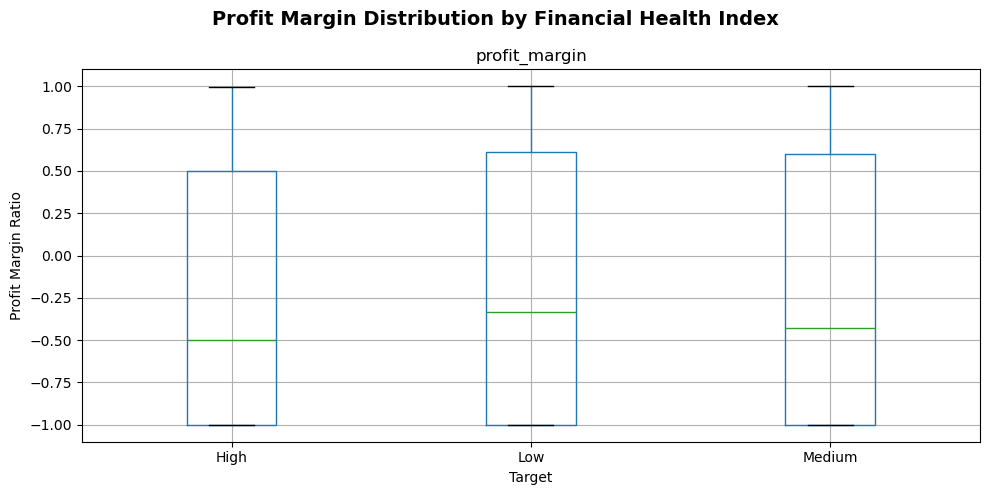


2️⃣ FINANCIAL ACCESS SCORE
----------------------------------------
Concept: How many formal financial services does the business use?
Includes: bank accounts, debit cards, internet banking, loans, insurance

✓ Created 'financial_access_score' feature
  Train - Non-null values: 9618
  Test - Non-null values: 2405

Sample statistics:
count    9618.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: financial_access_score, dtype: float64

📊 Financial Access Score by Target:
        mean  median  std
Target                   
High     0.0     0.0  0.0
Low      0.0     0.0  0.0
Medium   0.0     0.0  0.0


<Figure size 1000x500 with 0 Axes>

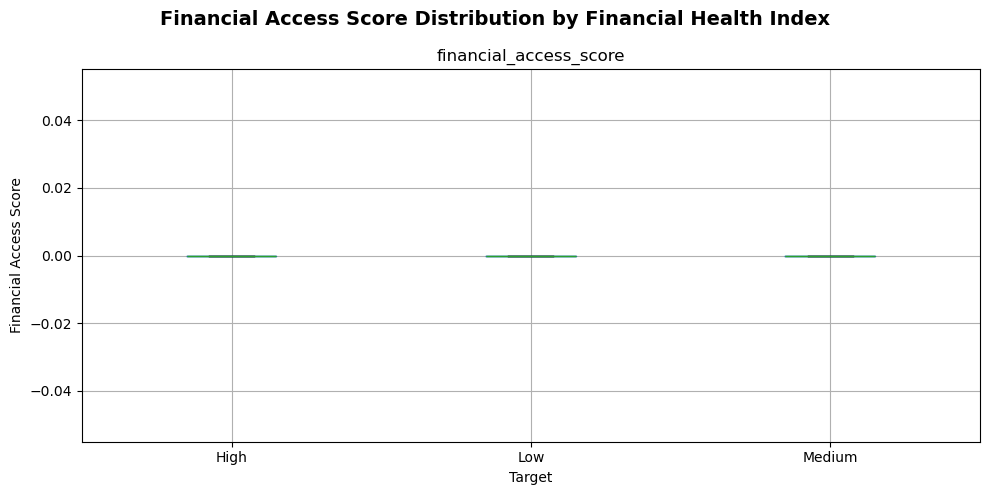


FEATURE ENGINEERING SUMMARY

✅ Successfully created 2 new features:

1. profit_margin:
   - Measures business profitability
   - Higher values = better financial performance
   - Useful for identifying financially healthy businesses

2. financial_access_score:
   - Measures access to formal financial services
   - Range: 0 (no access) to 1 (full access)
   - Reflects financial inclusion level

💡 MORE FEATURE IDEAS TO TRY:
   • Age bins (categorize owner_age into groups)
   • Income-to-expenses ratio
   • Business maturity (young vs established)
   • Risk perception score (combine attitude columns)
   • Country-specific features (encode regional patterns)
   • Insurance coverage index
   • Digital banking adoption flag

📝 NEXT STEPS:
   1. Add these features to your modeling pipeline
   2. Check feature importance after training
   3. Create more domain-specific features
   4. Test interaction features between variables
   5. Experiment with polynomial features for numerical data

🎯 Re

In [80]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING - GETTING STARTED")
print("=" * 60)

print("\n💡 Let's create some new features to boost your model performance!")
print("\nWe'll demonstrate 2 powerful feature engineering techniques:")

# Create copies to preserve original data
train_p = train.copy()
test_p = test.copy()

# ----------------------------------------
# Feature 1: Profit Margin Ratio
# ----------------------------------------
print("\n1️⃣ PROFIT MARGIN RATIO")
print("-" * 40)
print("Concept: How much profit does the business make relative to income?")
print("Formula: (personal_income - business_expenses) / personal_income")

def create_profit_margin(df):
    """
    Calculate profit margin ratio for each business.
    This indicates financial efficiency and sustainability.
    """
    # Handle division by zero and missing values
    profit_margin = []
    
    for idx, row in df.iterrows():
        income = row.get('personal_income', np.nan)
        expenses = row.get('business_expenses', np.nan)
        
        # Check if both values exist and income is not zero
        if pd.notna(income) and pd.notna(expenses) and income != 0:
            margin = (income - expenses) / income
            # Cap extreme values
            margin = max(-1, min(margin, 1))  # Keep between -1 and 1
        else:
            margin = np.nan
        
        profit_margin.append(margin)
    
    return profit_margin

train_p['profit_margin'] = create_profit_margin(train_p)
test_p['profit_margin'] = create_profit_margin(test_p)

print(f"\n✓ Created 'profit_margin' feature")
print(f"  Train - Non-null values: {train_p['profit_margin'].notna().sum()}")
print(f"  Test - Non-null values: {test_p['profit_margin'].notna().sum()}")
print("\nSample statistics:")
print(train_p['profit_margin'].describe())

# Show relationship with target
if 'Target' in train_p.columns:
    print("\n📊 Profit Margin by Target:")
    print(train_p.groupby('Target')['profit_margin'].agg(['mean', 'median', 'std']))
    
    # Visualize
    plt.figure(figsize=(10, 5))
    train_p.boxplot(column='profit_margin', by='Target', figsize=(10, 5))
    plt.suptitle('Profit Margin Distribution by Financial Health Index', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Profit Margin Ratio')
    plt.tight_layout()
    plt.show()

# ----------------------------------------
# Feature 2: Financial Access Score
# ----------------------------------------
print("\n2️⃣ FINANCIAL ACCESS SCORE")
print("-" * 40)
print("Concept: How many formal financial services does the business use?")
print("Includes: bank accounts, debit cards, internet banking, loans, insurance")

def create_financial_access_score(df):
    """
    Calculate a composite score of financial service access.
    Higher score = better access to formal financial services.
    """
    financial_features = [
        'has_bank_account', 'has_loan_account', 'has_internet_banking',
        'has_debit_card', 'medical_insurance', 'funeral_insurance'
    ]
    
    # Available features in the dataset
    available_features = [col for col in financial_features if col in df.columns]
    
    scores = []
    for idx, row in df.iterrows():
        score = 0
        valid_features = 0
        
        for feature in available_features:
            value = row.get(feature, np.nan)
            
            if pd.notna(value):
                valid_features += 1
                # Check for positive responses
                if value in ['Yes', 'Have now', 'have now']:
                    score += 1
                elif value in ['Used to have but don\'t have now', 'used to have']:
                    score += 0.5  # Partial credit for past access
        
        # Normalize by number of valid features checked
        if valid_features > 0:
            normalized_score = score / valid_features
        else:
            normalized_score = np.nan
        
        scores.append(normalized_score)
    
    return scores

train_p['financial_access_score'] = create_financial_access_score(train_p)
test_p['financial_access_score'] = create_financial_access_score(test_p)

print(f"\n✓ Created 'financial_access_score' feature")
print(f"  Train - Non-null values: {train_p['financial_access_score'].notna().sum()}")
print(f"  Test - Non-null values: {test_p['financial_access_score'].notna().sum()}")
print("\nSample statistics:")
print(train_p['financial_access_score'].describe())

# Show relationship with target
if 'Target' in train_p.columns:
    print("\n📊 Financial Access Score by Target:")
    print(train_p.groupby('Target')['financial_access_score'].agg(['mean', 'median', 'std']))
    
    # Visualize
    plt.figure(figsize=(10, 5))
    train_p.boxplot(column='financial_access_score', by='Target', figsize=(10, 5))
    plt.suptitle('Financial Access Score Distribution by Financial Health Index', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Financial Access Score')
    plt.tight_layout()
    plt.show()

# ----------------------------------------
# Summary
# ----------------------------------------
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("\n✅ Successfully created 2 new features:")
print("\n1. profit_margin:")
print("   - Measures business profitability")
print("   - Higher values = better financial performance")
print("   - Useful for identifying financially healthy businesses")

print("\n2. financial_access_score:")
print("   - Measures access to formal financial services")
print("   - Range: 0 (no access) to 1 (full access)")
print("   - Reflects financial inclusion level")

print("\n💡 MORE FEATURE IDEAS TO TRY:")
print("   • Age bins (categorize owner_age into groups)")
print("   • Income-to-expenses ratio")
print("   • Business maturity (young vs established)")
print("   • Risk perception score (combine attitude columns)")
print("   • Country-specific features (encode regional patterns)")
print("   • Insurance coverage index")
print("   • Digital banking adoption flag")

print("\n📝 NEXT STEPS:")
print("   1. Add these features to your modeling pipeline")
print("   2. Check feature importance after training")
print("   3. Create more domain-specific features")
print("   4. Test interaction features between variables")
print("   5. Experiment with polynomial features for numerical data")

print("\n🎯 Remember: Good features can make a bigger difference than complex models!")

# Save engineered datasets (optional)
print("\n💾 Your engineered dataframes are ready:")
print(f"   • train_fe: {train_p.shape}")
print(f"   • test_fe: {test_p.shape}")

print("\n" + "=" * 60)

In [81]:
X = train_p.drop(columns=['Target', 'ID'])
y = train_p['Target']

In [82]:
X_test = test_p.drop(columns=['ID'])

In [83]:
def change_object_to_cat(df):
  # changes objects columns to category and returns dataframe and list

  df = df.copy()
  list_str_obj_cols = df.columns[df.dtypes == "object"].tolist()
  for str_obj_col in list_str_obj_cols:
      df[str_obj_col] = df[str_obj_col].astype("category")

  return df,list_str_obj_cols
X, cat_list = change_object_to_cat(X)
X_test, cat_list = change_object_to_cat(X_test)

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=train[['country', 'Target']]
)

In [85]:
y_train

5111    Medium
3681    Medium
5087      High
2608    Medium
7554       Low
         ...  
5158    Medium
1863       Low
7278       Low
5116    Medium
6744       Low
Name: Target, Length: 7694, dtype: object

In [27]:
pip install lightgbm

In [86]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------
# 4. Train LightGBM
# -------------------------
model = LGBMClassifier()

model.fit(X_train, y_train)

# -------------------------
# 5. Predictions
# -------------------------
y_pred = model.predict(X_val)

# -------------------------
# 6. Evaluation
# -------------------------
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# -------------------------
# 7. Extract top 50 most important features
# -------------------------
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

top50 = feature_importances.sort_values("importance", ascending=False).head(50)
print("\nTop 50 Features:")
print(top50)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1270
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 37
[LightGBM] [Info] Start training from score -3.015951
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210580
Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.60      0.73        93
         Low       0.89      0.98      0.93      1256
      Medium       0.87      0.72      0.79       575

    accuracy                           0.88      1924
   macro avg       0.89      0.77      0.81      1924
weighted avg       0.88      0.88      0.88      1924


Confusion Matrix:
[[  56    4   33]
 [   0 1226   30]
 [   5  155  415]]

Top 50 

In [87]:
predictions = model.predict(X_test)

In [88]:
pred_df = pd.DataFrame({
    "ID": test["ID"].values,
    "pred_FHI": predictions
})

In [89]:
pred_df.to_csv('submission4.csv', index=False)

In [90]:
pred_df.head()

,ID,pred_FHI
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


In [91]:
predictions = model.predict(X_test)

pred_df = pd.DataFrame({
    "ID": test["ID"].values,
    "Target": predictions
})


pred_df.to_csv('submission4.csv', index=False)

pred_df

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low
...,...,...
2400,ID_FX7XJZ,Low
2401,ID_XAL1LX,Low
2402,ID_UHBP0F,Medium
2403,ID_GKIKR2,Medium
